c:\Users\ABI KRISHNAN\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset path: C:\Users\ABI KRISHNAN\.cache\kagglehub\datasets\beatoa\spamassassin-public-corpus\versions\2
Total emails : 4198
Spam         : 1397
Ham          : 2801

Cleaning and tokenizing emails …
Preprocessing done.
label
Ham     2801
Spam    1397
Name: count, dtype: int64

─── Training Naive Bayes ───
              precision    recall  f1-score   support

         Ham       0.96      0.94      0.95       560
        Spam       0.89      0.93      0.91       280

    accuracy                           0.94       840
   macro avg       0.93      0.93      0.93       840
weighted avg       0.94      0.94      0.94       840


─── Training SVM (GridSearchCV) ───
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best C = 1  |  CV F1 = 0.9838
              precision    recall  f1-score   support

         Ham       1.00      0.98      0.99       560
        Spam       0.97      0.99      0.98       280

    accuracy                           0.99       840
   macro avg       

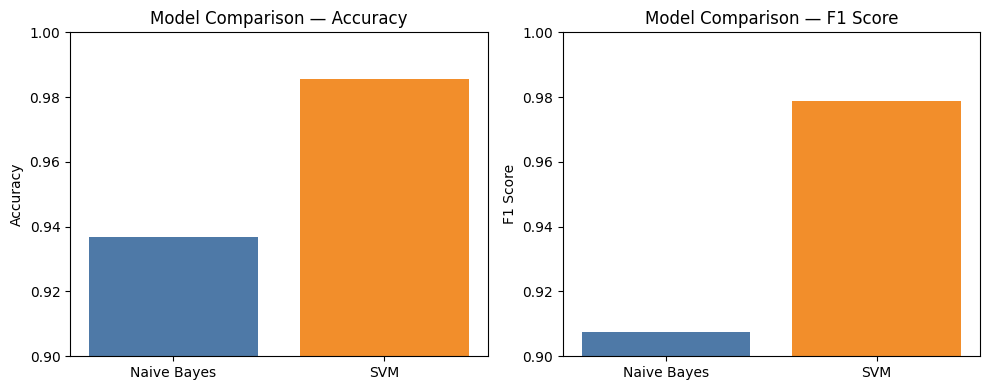

Comparison chart saved to model_comparison.png


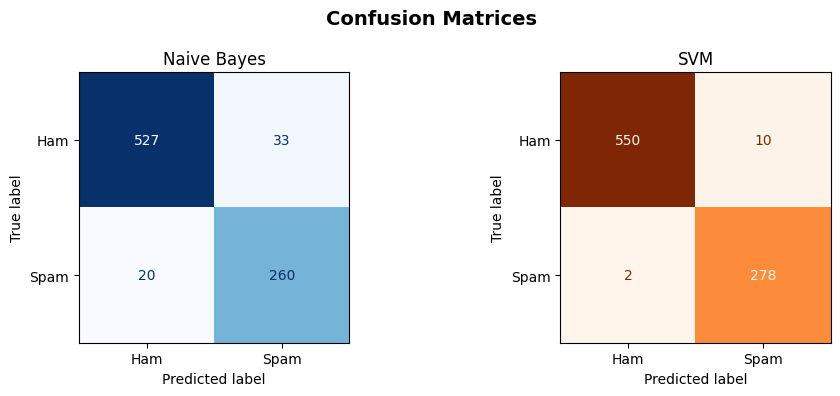

Confusion matrices saved to confusion_matrices.png

Best model (SVM) + vectorizer saved to models/

=== Sample Predictions ===
  [SPAM  (spam prob: 65.3%)]  Meeting scheduled at 10 am tomorrow – please confirm.
  [SPAM  (spam prob: 97.7%)]  Congratulations! You have WON a FREE lottery. Click here NOW!!!
  [SPAM  (spam prob: 63.8%)]  Please find attached the Q3 project report for your review.
  [SPAM  (spam prob: 80.3%)]  URGENT: Your bank account has been compromised. Verify immediately.


In [1]:
"""
============================================================
  EMAIL SPAM CLASSIFICATION USING NLP AND MACHINE LEARNING
============================================================
Models    : Naive Bayes, SVM, LSTM
Features  : TF-IDF (NB & SVM), Word Embeddings (LSTM)
Dataset   : SpamAssassin Public Corpus
Evaluation: Confusion Matrix, F1-Score, ROC-AUC
============================================================
"""

import os
import re
import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import kagglehub

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, f1_score,
                              accuracy_score, roc_auc_score)

# ── 1. Download Dataset ──────────────────────────────────
path = kagglehub.dataset_download("beatoa/spamassassin-public-corpus")
print("Dataset path:", path)

# ── 2. Load Emails ───────────────────────────────────────
emails, labels = [], []

def read_emails(folder_path, label):
    for root, _, files in os.walk(folder_path):
        if "__MACOSX" in root:
            continue
        for fname in files:
            if fname.startswith('.'):
                continue
            fpath = os.path.join(root, fname)
            if os.path.isfile(fpath):
                try:
                    with open(fpath, "r", encoding="latin-1") as f:
                        emails.append(f.read())
                        labels.append(label)
                except Exception as e:
                    print(f"Error reading {fpath}: {e}")

read_emails(os.path.join(path, "spam_2"),   1)
read_emails(os.path.join(path, "easy_ham"), 0)
read_emails(os.path.join(path, "hard_ham"), 0)

print(f"Total emails : {len(emails)}")
print(f"Spam         : {labels.count(1)}")
print(f"Ham          : {labels.count(0)}")

# ── 3. Preprocessing Pipeline ────────────────────────────
# (tokenization, stop-word removal, lemmatization)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',  quiet=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def extract_body(raw):
    """Strip email headers — everything before the first blank line."""
    parts = re.split(r'\n\n', raw, maxsplit=1)
    return parts[1] if len(parts) > 1 else raw

def clean_text(text):
    """Full preprocessing pipeline."""
    text = extract_body(text)           # remove headers
    text = text.lower()                 # lowercase
    text = re.sub(r'http\S+|www\.\S+', ' url ',   text)  # URLs
    text = re.sub(r'\S+@\S+',           ' email ', text)  # emails
    text = re.sub(r'\d+',               ' num ',   text)  # numbers
    text = re.sub(r'[^\w\s]',           ' ',       text)  # punctuation
    # tokenization + stop-word removal + lemmatization
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words
             if w not in stop_words and len(w) > 1]
    return " ".join(words)

df = pd.DataFrame({"email": emails, "label": labels})
print("\nCleaning and tokenizing emails …")
df['clean_text'] = df['email'].apply(clean_text)
print("Preprocessing done.")
print(df['label'].value_counts().rename({0: 'Ham', 1: 'Spam'}))

# ── 4. Train / Test Split (stratified) ──────────────────
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['label'],
    test_size=0.2, random_state=42, stratify=df['label']
)

# ── 5. TF-IDF Feature Extraction ─────────────────────────
tfidf = TfidfVectorizer(
    max_features=10_000,
    ngram_range=(1, 2),      # unigrams + bigrams
    sublinear_tf=True,
    min_df=2,
    strip_accents='unicode',
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

# ════════════════════════════════════════════════════════
#  MODEL 1 — Naive Bayes
# ════════════════════════════════════════════════════════
print("\n─── Training Naive Bayes ───")
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
y_pred_nb = nb.predict(X_test_tfidf)

print(classification_report(y_test, y_pred_nb, target_names=["Ham", "Spam"]))

# ════════════════════════════════════════════════════════
#  MODEL 2 — SVM (optimised with GridSearchCV)
# ════════════════════════════════════════════════════════
print("\n─── Training SVM (GridSearchCV) ───")
param_grid = {'C': [0.01, 0.1, 1, 10]}
grid = GridSearchCV(
    LinearSVC(class_weight='balanced', max_iter=2000),
    param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1
)
grid.fit(X_train_tfidf, y_train)
print(f"Best C = {grid.best_params_['C']}  |  CV F1 = {grid.best_score_:.4f}")

# Calibrate for probability scores
svm = CalibratedClassifierCV(
    LinearSVC(C=grid.best_params_['C'],
              class_weight='balanced', max_iter=2000),
    cv=3
)
svm.fit(X_train_tfidf, y_train)
y_pred_svm  = svm.predict(X_test_tfidf)
y_prob_svm  = svm.predict_proba(X_test_tfidf)[:, 1]

print(classification_report(y_test, y_pred_svm, target_names=["Ham", "Spam"]))
print(f"ROC-AUC (SVM): {roc_auc_score(y_test, y_prob_svm):.4f}")

# Cross-validation score
cv_scores = cross_val_score(
    LinearSVC(C=grid.best_params_['C'], class_weight='balanced', max_iter=2000),
    X_train_tfidf, y_train, cv=5, scoring='f1'
)
print(f"Cross-val F1  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# ════════════════════════════════════════════════════════
#  MODEL 3 — LSTM (Word Embeddings)
# ════════════════════════════════════════════════════════
print("\n─── Training LSTM ───")
try:
    from tensorflow.keras.preprocessing.text import Tokenizer
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping

    MAX_WORDS  = 10_000
    MAX_LEN    = 150

    tokenizer_lstm = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
    tokenizer_lstm.fit_on_texts(X_train)

    X_train_seq = pad_sequences(
        tokenizer_lstm.texts_to_sequences(X_train), maxlen=MAX_LEN)
    X_test_seq  = pad_sequences(
        tokenizer_lstm.texts_to_sequences(X_test),  maxlen=MAX_LEN)

    y_train_arr = np.array(y_train)
    y_test_arr  = np.array(y_test)

    lstm_model = Sequential([
        Embedding(input_dim=MAX_WORDS, output_dim=64, input_length=MAX_LEN),
        LSTM(64, return_sequences=True),
        Dropout(0.3),
        LSTM(32),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])

    lstm_model.compile(
        loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

    early_stop = EarlyStopping(
        monitor='val_loss', patience=2, restore_best_weights=True)

    history = lstm_model.fit(
        X_train_seq, y_train_arr,
        epochs=10, batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=1
    )

    y_pred_lstm = (lstm_model.predict(X_test_seq) > 0.5).astype("int32")
    lstm_available = True

    print(classification_report(y_test_arr, y_pred_lstm, target_names=["Ham","Spam"]))

    # Plot LSTM training history
    plt.figure()
    plt.plot(history.history['accuracy'],     label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('LSTM — Accuracy vs Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.savefig("lstm_training.png", dpi=120)
    plt.show()
    print("LSTM training plot saved to lstm_training.png")

except ImportError:
    print("TensorFlow not installed — skipping LSTM.")
    print("Install with: py -m pip install tensorflow")
    lstm_available   = False
    y_pred_lstm      = None

# ── 6. Model Comparison ──────────────────────────────────
print("\n═══════════════════════════════════")
print("       MODEL COMPARISON SUMMARY     ")
print("═══════════════════════════════════")

results = {
    "Model"   : ["Naive Bayes", "SVM"],
    "Accuracy": [accuracy_score(y_test, y_pred_nb),
                 accuracy_score(y_test, y_pred_svm)],
    "F1 Score": [f1_score(y_test, y_pred_nb),
                 f1_score(y_test, y_pred_svm)],
}

if lstm_available and y_pred_lstm is not None:
    results["Model"].append("LSTM")
    results["Accuracy"].append(accuracy_score(y_test_arr, y_pred_lstm))
    results["F1 Score"].append(f1_score(y_test_arr, y_pred_lstm))

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(df_results["Model"], df_results["Accuracy"],
            color=['#4e79a7', '#f28e2b', '#e15759'])
axes[0].set_title("Model Comparison — Accuracy")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0.9, 1.0)

axes[1].bar(df_results["Model"], df_results["F1 Score"],
            color=['#4e79a7', '#f28e2b', '#e15759'])
axes[1].set_title("Model Comparison — F1 Score")
axes[1].set_ylabel("F1 Score")
axes[1].set_ylim(0.9, 1.0)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=120)
plt.show()
print("Comparison chart saved to model_comparison.png")

# ── 7. Confusion Matrices ────────────────────────────────
n_models = 3 if lstm_available else 2
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_nb),
    display_labels=["Ham", "Spam"]
).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title("Naive Bayes")

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_svm),
    display_labels=["Ham", "Spam"]
).plot(ax=axes[1], cmap='Oranges', colorbar=False)
axes[1].set_title("SVM")

if lstm_available:
    ConfusionMatrixDisplay(
        confusion_matrix(y_test_arr, y_pred_lstm),
        display_labels=["Ham", "Spam"]
    ).plot(ax=axes[2], cmap='Reds', colorbar=False)
    axes[2].set_title("LSTM")

plt.suptitle("Confusion Matrices", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=120)
plt.show()
print("Confusion matrices saved to confusion_matrices.png")

# ── 8. Save Best Model (SVM) ─────────────────────────────
os.makedirs("models", exist_ok=True)
joblib.dump(svm,   "models/spam_model.pkl")
joblib.dump(tfidf, "models/vectorizer.pkl")
print("\nBest model (SVM) + vectorizer saved to models/")

# ── 9. Smoke Test ────────────────────────────────────────
def predict(text):
    vec  = tfidf.transform([clean_text(text)])
    prob = svm.predict_proba(vec)[0]
    return f"{'SPAM' if prob[1]>0.5 else 'HAM'}  (spam prob: {prob[1]:.1%})"

samples = [
    "Meeting scheduled at 10 am tomorrow – please confirm.",
    "Congratulations! You have WON a FREE lottery. Click here NOW!!!",
    "Please find attached the Q3 project report for your review.",
    "URGENT: Your bank account has been compromised. Verify immediately.",
]

print("\n=== Sample Predictions ===")
for s in samples:
    print(f"  [{predict(s)}]  {s[:70]}")